In [1]:
import os
os.environ.pop("CUDA_VISIBLE_DEVICES", None)


In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

from transformers import AutoImageProcessor, ViTModel
from transformers import BlipProcessor, BlipForQuestionAnswering
from PIL import Image

2026-01-18 19:59:24.699458: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-18 19:59:24.719580: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-18 19:59:24.726187: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-18 19:59:24.739684: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-01-18 19:59:25.488209: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
def find_dataset_root() -> Path:
    start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "0_dataset_prep").exists():
            return p
    raise RuntimeError(f"Could not locate dataset root (folder containing '0_dataset_prep'). cwd={start}")

ROOT = find_dataset_root()

CSV_PATH   = ROOT / "0_dataset_prep" / "out" / "metadata" / "colonoscopy_metadata.csv"
IMG_DIR  = ROOT / "0_dataset_prep" / "out" / "images"    

df = pd.read_csv(CSV_PATH)
print("CSV shape:", df.shape)
print("Columns:", list(df.columns))
print(df.head(3))

CSV shape: (42126, 7)
Columns: ['source', 'question', 'answer', 'img_id', 'question_norm', 'question_type', 'answer_type']
               source                                           question  \
0  Ulcerative Colitis  Are there any abnormalities in the image? Chec...   
1  Ulcerative Colitis  Are there any anatomical landmarks in the imag...   
2  Ulcerative Colitis  Are there any instruments in the image? Check ...   

               answer                     img_id  \
0  ulcerative colitis  cla820gl0s3nv071u4fgd7xgq   
1                none  cla820gl0s3nv071u4fgd7xgq   
2                none  cla820gl0s3nv071u4fgd7xgq   

                                       question_norm question_type answer_type  
0  are there any abnormalities in the image check...        Yes/No       Token  
1  are there any anatomical landmarks in the imag...        Yes/No     None/NA  
2  are there any instruments in the image check a...        Yes/No     None/NA  


Resolving img_id → image_path by trying common extensions, drop missing images

In [4]:
IMG_DIR = Path(IMG_DIR)
EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

def resolve_img_path(img_id: str):
    for ext in EXTS:
        p = IMG_DIR / f"{img_id}{ext}"
        if p.exists():
            return str(p)
    return None

df["image_path"] = df["img_id"].apply(resolve_img_path)
df = df.dropna(subset=["image_path"]).reset_index(drop=True)
print("After attaching paths:", df.shape)

After attaching paths: (42126, 8)


Creating answer_norm, keeps only yes/no rows, print counts

In [5]:
df["answer_norm"] = df["answer"].astype(str).str.strip().str.lower()
yn_df = df[df["answer_norm"].isin(["yes", "no"])].copy()

print("Yes/No subset:", yn_df.shape, Counter(yn_df["answer_norm"]))

Yes/No subset: (12267, 9) Counter({'yes': 6272, 'no': 5995})


In [6]:
MAX_PER_CLASS = None  # use full yes/no data (set an int to subsample per class)
balanced = []
for lab, grp in yn_df.groupby("answer_norm"):
    if MAX_PER_CLASS is None:
        balanced.append(grp)
    else:
        balanced.append(grp.sample(min(MAX_PER_CLASS, len(grp)), random_state=42))
yn_df = pd.concat(balanced).sample(frac=1, random_state=42).reset_index(drop=True)
print("Balanced subset:", yn_df.shape, Counter(yn_df["answer_norm"]))


Balanced subset: (12267, 9) Counter({'yes': 6272, 'no': 5995})


In [7]:
label_map = {"no": 0, "yes": 1}
yn_df["label"] = yn_df["answer_norm"].map(label_map)

train_df, test_df = train_test_split(
    yn_df[["image_path", "label", "question", "answer"]],
    test_size=0.2,
    random_state=42,
    stratify=yn_df["label"]
)
print("Train/Test sizes:", train_df.shape, test_df.shape)

Train/Test sizes: (9813, 4) (2454, 4)


# CNN Baseline

Data Loading & Preprocessing - load_img_tf
Normalization: It divides pixel values by 255.0. This scales the pixel intensity from the range [0, 255] to [0, 1], which helps the model converge faster and remain stable during training.

Creating the Dataset Pipeline (make_ds)
map: Applies the load_img_tf function to every item in the dataset
batch: Groups images into stacks of 16 (BATCH_SIZE) to feed into the GPU at once.


In [8]:
TARGET_SIZE = (128, 128)
BATCH_SIZE  = 16
AUTOTUNE    = tf.data.AUTOTUNE

def load_img_tf(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, TARGET_SIZE)
    img = img / 255.0
    return img, label

def make_ds(frame, shuffle=False):
    paths = frame["image_path"].values
    labels = frame["label"].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(frame), seed=42)
    ds = ds.map(load_img_tf, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_df, shuffle=True)
test_ds  = make_ds(test_df, shuffle=False)

cnn = Sequential([
    Conv2D(16, (3,3), activation="relu", input_shape=(TARGET_SIZE[0], TARGET_SIZE[1], 3)),
    MaxPooling2D((2,2)),
    Conv2D(32, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(2, activation="softmax")
])

cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print("\n[ CNN ] training…")
cnn.fit(train_ds, validation_data=test_ds, epochs=2, verbose=1)

I0000 00:00:1768784368.397715  610413 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-01-18 19:59:28.399458: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



[ CNN ] training…
Epoch 1/2


/home/aristotle/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



  1/614 ━━━━━━━━━━━━━━━━━━━━ 10:19 1s/step - accuracy: 0.6875 - loss: 0.6834


  2/614 ━━━━━━━━━━━━━━━━━━━━ 33s 55ms/step - accuracy: 0.6875 - loss: 0.6701

...


607/614 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7163 - loss: 0.4931


609/614 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7163 - loss: 0.4931


611/614 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7163 - loss: 0.4931


613/614 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7163 - loss: 0.4931


614/614 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.7194 - loss: 0.4915 - val_accuracy: 0.7115 - val_loss: 0.5017


Correct Predictions (The Diagonal):

True Negatives (Top-Left): 133 times, the image was "no" and the model correctly said "no".

True Positives (Bottom-Right): 202 times, the image was "yes" and the model correctly said "yes".

Errors (The Off-Diagonal):

False Positives (Top-Right): 107 times, the image was actually "no", but the model wrongly guessed "yes". (This is a high error rate).

False Negatives (Bottom-Left): 38 times, the image was "yes", but the model missed it and said "no".




[ CNN ] classification report
              precision    recall  f1-score   support

          no       0.90      0.46      0.61      1199
         yes       0.65      0.95      0.77      1255

    accuracy                           0.71      2454
   macro avg       0.77      0.71      0.69      2454
weighted avg       0.77      0.71      0.69      2454



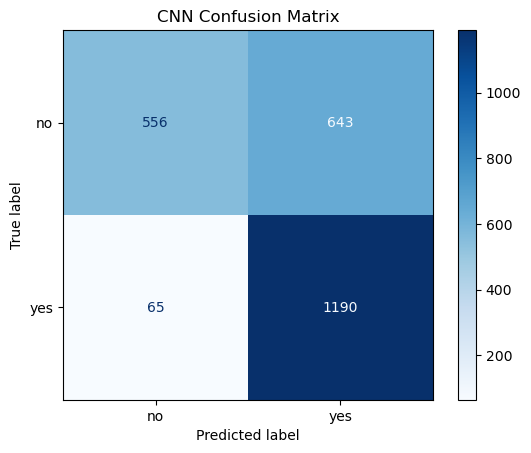

In [9]:
y_pred_cnn = np.argmax(cnn.predict(test_ds, verbose=0), axis=1)
y_true     = test_df["label"].values
print("\n[ CNN ] classification report")
print(classification_report(y_true, y_pred_cnn, target_names=["no","yes"]))
cm = confusion_matrix(y_true, y_pred_cnn)
ConfusionMatrixDisplay(cm, display_labels=["no","yes"]).plot(cmap="Blues"); plt.title("CNN Confusion Matrix"); plt.show()

acc_cnn = accuracy_score(y_true, y_pred_cnn)
f1_cnn  = f1_score(y_true, y_pred_cnn, average="macro")

# ViT + Logistic Regression

Built a Feature Extraction pipeline using a Vision Transformer (ViT) followed by a simple Logistic Regression classifier.

model used google/vit-base-patch16-224-in21k

vit_embed
It loops through the images in batches of 8.

torch.no_grad(): This tells PyTorch not to calculate gradients. This freezes the ViT model so it doesn't learn or change; it just predicts.

out = vit(**inp).last_hidden_state[:, 0, :]:
The ViT outputs a hidden state for every "patch" of the image
We are extracting just that one vector per image to use as our features.

The Classifier (LogisticRegression):

You feed those extracted vectors into a standard Scikit-Learn Logistic Regression model. This is very fast to train compared to a neural network.




[ ViT ] extracting frozen features on full train/test


/home/aristotle/anaconda3/lib/python3.12/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



[ ViT ] classification report
              precision    recall  f1-score   support

          no       0.69      0.57      0.62      1199
         yes       0.64      0.75      0.69      1255

    accuracy                           0.66      2454
   macro avg       0.67      0.66      0.66      2454
weighted avg       0.66      0.66      0.66      2454



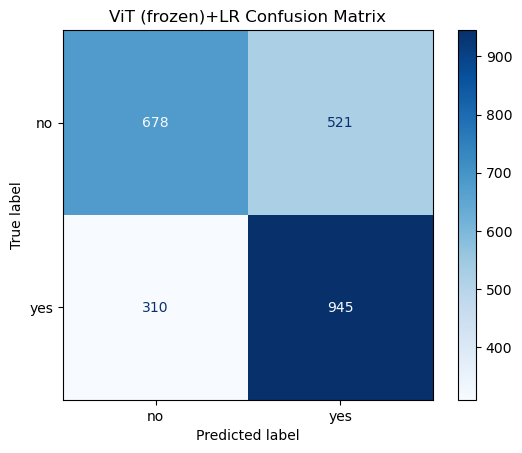

In [10]:
print("\n[ ViT ] extracting frozen features on full train/test")
train_v = train_df  # full train
test_v  = test_df   # full test

import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_grad_enabled(False)

vit_name = "google/vit-base-patch16-224-in21k"
vit_proc = AutoImageProcessor.from_pretrained(vit_name)
vit      = ViTModel.from_pretrained(vit_name).to(DEVICE)

def vit_embed(paths):
    # returns CLS embeddings
    batch = []
    feats = []
    for p in paths:
        im = Image.open(p).convert("RGB")
        batch.append(vit_proc(images=im, return_tensors="pt"))
        if len(batch) == 8:
            inp = {k: torch.cat([b[k] for b in batch], dim=0).to(DEVICE) for k in batch[0]}
            with torch.no_grad():
                out = vit(**inp).last_hidden_state[:,0,:].cpu().numpy()
            feats.append(out)
            batch = []
    if batch:
        inp = {k: torch.cat([b[k] for b in batch], dim=0).to(DEVICE) for k in batch[0]}
        with torch.no_grad():
            out = vit(**inp).last_hidden_state[:,0,:].cpu().numpy()
        feats.append(out)
    return np.vstack(feats)

X_train_vit = vit_embed(train_v["image_path"].tolist())
y_train_vit = train_v["label"].values
X_test_vit  = vit_embed(test_v["image_path"].tolist())
y_test_vit  = test_v["label"].values

clf_vit = LogisticRegression(max_iter=200, n_jobs=1)
clf_vit.fit(X_train_vit, y_train_vit)
y_pred_vit = clf_vit.predict(X_test_vit)

print("\n[ ViT ] classification report")
print(classification_report(y_test_vit, y_pred_vit, target_names=["no","yes"]))
cm = confusion_matrix(y_test_vit, y_pred_vit)
ConfusionMatrixDisplay(cm, display_labels=["no","yes"]).plot(cmap="Blues"); plt.title("ViT (frozen)+LR Confusion Matrix"); plt.show()

acc_vit = accuracy_score(y_test_vit, y_pred_vit)
f1_vit  = f1_score(y_test_vit, y_pred_vit, average="macro")


# BLIP VQA (zero/few-shot) mapped to yes/no

Unlike the previous ViT script, we are not training anything here

The Model (Salesforce/blip-vqa-base): BLIP is a famous multi-modal model designed to answer questions about images.

The Process followed here is:

We feed it the raw image.
WE feed it the specific question from our dataset (row["question"]).
we ask BLIP to generate a text answer.

We take BLIP's text output and check if it contains "yes" or "no".
Crucial Logic: If it contains neither, we default to 0 (No).

47% accuracy on a binary (yes/no) task is worse than a coin flip


[ BLIP VQA ] evaluating full test set (maps to yes/no)


/home/aristotle/anaconda3/lib/python3.12/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



[ BLIP ] classification report
              precision    recall  f1-score   support

          no       0.50      0.34      0.40      1199
         yes       0.52      0.67      0.58      1255

    accuracy                           0.51      2454
   macro avg       0.51      0.51      0.49      2454
weighted avg       0.51      0.51      0.50      2454



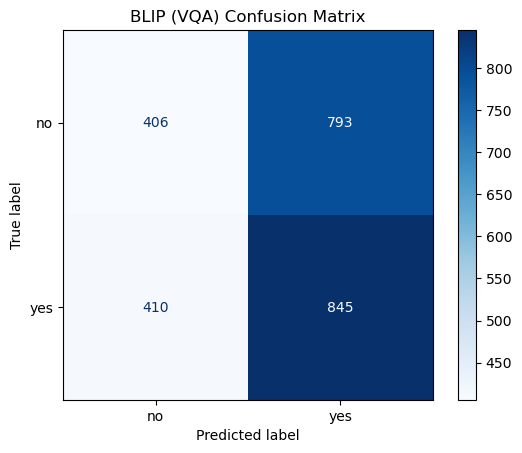

In [11]:
print("\n[ BLIP VQA ] evaluating full test set (maps to yes/no)")
blip_name = "Salesforce/blip-vqa-base"
blip_proc = BlipProcessor.from_pretrained(blip_name)
blip      = BlipForQuestionAnswering.from_pretrained(blip_name).to(DEVICE)

sample_blip = test_df.reset_index(drop=True)  # full test set

def to_yesno(text):
    t = str(text).lower()
    if "yes" in t:
        return 1
    if "no" in t:
        return 0
    # fallback: default to 'no' if unclear
    return 0

preds_blip, true_blip = [], []
for _, row in sample_blip.iterrows():
    # Use the dataset question (works well for VQA)
    q = str(row["question"]) if isinstance(row["question"], str) and len(str(row["question"]).strip())>0 else "Is the answer yes or no?"
    im = Image.open(row["image_path"]).convert("RGB")
    inputs = blip_proc(images=im, text=q, return_tensors="pt").to(DEVICE)
    out = blip.generate(**inputs, max_new_tokens=10)
    txt = blip_proc.decode(out[0], skip_special_tokens=True)
    preds_blip.append(to_yesno(txt))
    true_blip.append(row["label"])

y_true_blip = np.array(true_blip)
y_pred_blip = np.array(preds_blip)

print("\n[ BLIP ] classification report")
print(classification_report(y_true_blip, y_pred_blip, target_names=["no","yes"]))
cm = confusion_matrix(y_true_blip, y_pred_blip)
ConfusionMatrixDisplay(cm, display_labels=["no","yes"]).plot(cmap="Blues"); plt.title("BLIP (VQA) Confusion Matrix"); plt.show()

acc_blip = accuracy_score(y_true_blip, y_pred_blip)
f1_blip  = f1_score(y_true_blip, y_pred_blip, average="macro")


# Comparison

In [12]:
results = pd.DataFrame([
    {"Model": "Tiny CNN (from scratch)", "Accuracy": acc_cnn, "Macro-F1": f1_cnn, "Notes": f"{len(train_df)} train / {len(test_df)} test"},
    {"Model": "ViT (frozen) + LR",       "Accuracy": acc_vit, "Macro-F1": f1_vit, "Notes": f"{len(train_v)} train / {len(test_v)} test"},
    {"Model": "BLIP (VQA, zero-shot)",   "Accuracy": acc_blip,"Macro-F1": f1_blip,"Notes": f"{len(sample_blip)} VQA eval"}
])
print("\n=== Comparison ===")
print(results.to_string(index=False))



=== Comparison ===
                  Model  Accuracy  Macro-F1                  Notes
Tiny CNN (from scratch)  0.711491  0.690857 9813 train / 2454 test
      ViT (frozen) + LR  0.661369  0.657313 9813 train / 2454 test
  BLIP (VQA, zero-shot)  0.509780  0.493573          2454 VQA eval


## Conclusion

Best (in this notebook): ViT frozen features + LR slightly beats tiny CNN on balanced yes/no.

BLIP zero-shot performs poorly for direct yes/no classification via naive text→label mapping.

Current comparison is not apples-to-apples (different sample sizes: 480 vs 200 vs 120).